# BGL Raw Dataset Exploratory Analysis

This notebook analyzes `artifacts/datasets/BGL/raw/BGL_raw.csv`, the merged BGL raw log dataset containing raw log metadata plus `EventId` and `EventTemplate` from the structured parser.

The file is large, so the full-dataset analysis below streams the CSV in chunks and caches compact summary tables under `artifacts/datasets/BGL/analysis/`.

In [1]:
from __future__ import annotations

import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 30)

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "experiments/behavior_log/artifacts/datasets/BGL/raw/BGL_raw.csv").exists():
            return candidate
        nested = candidate / "log-to-vec-benchmark"
        if (nested / "experiments/behavior_log/artifacts/datasets/BGL/raw/BGL_raw.csv").exists():
            return nested
    raise FileNotFoundError("Could not find log-to-vec-benchmark project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "experiments/behavior_log/artifacts/datasets/BGL/raw/BGL_raw.csv"
ANALYSIS_DIR = PROJECT_ROOT / "experiments/behavior_log/artifacts/datasets/BGL/analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_JSON = ANALYSIS_DIR / "BGL_raw_summary.json"
EVENT_COUNTS_CSV = ANALYSIS_DIR / "BGL_raw_event_counts.csv"
TEMPLATE_COUNTS_CSV = ANALYSIS_DIR / "BGL_raw_template_counts.csv"
LEVEL_COUNTS_CSV = ANALYSIS_DIR / "BGL_raw_level_counts.csv"
COMPONENT_COUNTS_CSV = ANALYSIS_DIR / "BGL_raw_component_counts.csv"
LABEL_COUNTS_CSV = ANALYSIS_DIR / "BGL_raw_label_counts.csv"
DAILY_COUNTS_CSV = ANALYSIS_DIR / "BGL_raw_daily_counts.csv"

DATA_PATH

PosixPath('/home/lyra/projects/log-to-vec-benchmark/experiments/behavior_log/artifacts/datasets/BGL/raw/BGL_raw.csv')

## Quick Preview

Start with a small sample to inspect columns, dtypes, and typical values.

In [2]:
sample = pd.read_csv(DATA_PATH, nrows=20_000)
sample.head()

,LineId,Label,Timestamp,Date,Node,Time,NodeRepeat,Type,Component,Level,Content,EventId,EventTemplate
0,1,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.363779,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,E208,instruction cache parity error corrected
1,2,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.527847,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,E208,instruction cache parity error corrected
2,3,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.675872,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,E208,instruction cache parity error corrected
3,4,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.823719,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,E208,instruction cache parity error corrected
4,5,-,1117838570,2005.06.03,R02-M1-N0-C:J12-U11,2005-06-03-15.42.50.982731,R02-M1-N0-C:J12-U11,RAS,KERNEL,INFO,instruction cache parity error corrected,E208,instruction cache parity error corrected


In [3]:
sample.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   LineId         20000 non-null  int64 
 1   Label          20000 non-null  object
 2   Timestamp      20000 non-null  int64 
 3   Date           20000 non-null  object
 4   Node           19998 non-null  object
 5   Time           20000 non-null  object
 6   NodeRepeat     19998 non-null  object
 7   Type           20000 non-null  object
 8   Component      20000 non-null  object
 9   Level          20000 non-null  object
 10  Content        20000 non-null  object
 11  EventId        20000 non-null  object
 12  EventTemplate  20000 non-null  object
dtypes: int64(2), object(11)
memory usage: 15.2 MB


In [4]:
sample.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
LineId,20000.0,NaN,NaN,NaN,10000.5,5773.647028,1.0,5000.75,10000.5,15000.25,20000.0
Label,20000,2,-,19919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Timestamp,20000.0,NaN,NaN,NaN,1117871641.8574,48886.441145,1117838570.0,1117840660.0,1117845126.0,1117937037.0,1117956963.0
Date,20000,3,2005.06.03,14732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Node,19998,6340,R02-M1-N0-C:J12-U11,4865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,20000,20000,2005-06-05-00.36.02.189481,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NodeRepeat,19998,6340,R02-M1-N0-C:J12-U11,4865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,20000,1,RAS,20000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Component,20000,4,KERNEL,19800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Level,20000,2,INFO,19743,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Full Dataset Aggregation

This cell scans the full CSV once and writes reusable summary tables. If the cached files already exist, it loads them instead.

In [5]:
def _counter_to_frame(counter: Counter, key_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(counter.most_common(), columns=[key_name, "count"])
    if len(frame):
        frame["share"] = frame["count"] / frame["count"].sum()
        frame.insert(0, "rank", range(1, len(frame) + 1))
    return frame


def build_or_load_summary(force: bool = False, chunksize: int = 500_000):
    cache_files = [
        SUMMARY_JSON,
        EVENT_COUNTS_CSV,
        TEMPLATE_COUNTS_CSV,
        LEVEL_COUNTS_CSV,
        COMPONENT_COUNTS_CSV,
        LABEL_COUNTS_CSV,
        DAILY_COUNTS_CSV,
    ]
    if not force and all(path.exists() for path in cache_files):
        summary = json.loads(SUMMARY_JSON.read_text(encoding="utf-8"))
        tables = {
            "event_counts": pd.read_csv(EVENT_COUNTS_CSV),
            "template_counts": pd.read_csv(TEMPLATE_COUNTS_CSV),
            "level_counts": pd.read_csv(LEVEL_COUNTS_CSV),
            "component_counts": pd.read_csv(COMPONENT_COUNTS_CSV),
            "label_counts": pd.read_csv(LABEL_COUNTS_CSV),
            "daily_counts": pd.read_csv(DAILY_COUNTS_CSV, parse_dates=["date"]),
        }
        return summary, tables

    event_counts = Counter()
    template_counts = Counter()
    level_counts = Counter()
    component_counts = Counter()
    label_counts = Counter()
    daily_total_counts = Counter()
    daily_anomaly_counts = Counter()
    content_lengths = []
    template_lengths = []

    total_rows = 0
    missing_counts = Counter()
    min_timestamp = None
    max_timestamp = None

    usecols = [
        "LineId",
        "Label",
        "Timestamp",
        "Date",
        "Node",
        "Component",
        "Level",
        "Content",
        "EventId",
        "EventTemplate",
    ]
    dtypes = {
        "LineId": "int64",
        "Label": "string",
        "Timestamp": "int64",
        "Date": "string",
        "Node": "string",
        "Component": "string",
        "Level": "string",
        "Content": "string",
        "EventId": "string",
        "EventTemplate": "string",
    }

    for i, chunk in enumerate(pd.read_csv(DATA_PATH, usecols=usecols, dtype=dtypes, chunksize=chunksize), start=1):
        total_rows += len(chunk)
        print(f"chunk {i}: total rows = {total_rows:,}")

        event_counts.update(chunk["EventId"].fillna("<missing>").tolist())
        template_counts.update(chunk["EventTemplate"].fillna("<missing>").tolist())
        level_counts.update(chunk["Level"].fillna("<missing>").tolist())
        component_counts.update(chunk["Component"].fillna("<missing>").tolist())
        label_counts.update(chunk["Label"].fillna("<missing>").tolist())

        date = pd.to_datetime(chunk["Date"], format="%Y.%m.%d", errors="coerce")
        daily_total_counts.update(date.dt.date.dropna().astype(str).tolist())

        is_anomaly = chunk["Label"].fillna("-") != "-"
        daily_anomaly_counts.update(date[is_anomaly].dt.date.dropna().astype(str).tolist())

        content_lengths.extend(chunk["Content"].fillna("").str.split().str.len().astype("int32").tolist())
        template_lengths.extend(chunk["EventTemplate"].fillna("").str.split().str.len().astype("int32").tolist())

        missing_counts.update(chunk.isna().sum().to_dict())

        chunk_min_timestamp = int(chunk["Timestamp"].min())
        chunk_max_timestamp = int(chunk["Timestamp"].max())
        min_timestamp = chunk_min_timestamp if min_timestamp is None else min(min_timestamp, chunk_min_timestamp)
        max_timestamp = chunk_max_timestamp if max_timestamp is None else max(max_timestamp, chunk_max_timestamp)

    event_df = _counter_to_frame(event_counts, "event_id")
    template_df = _counter_to_frame(template_counts, "event_template")
    level_df = _counter_to_frame(level_counts, "level")
    component_df = _counter_to_frame(component_counts, "component")
    label_df = _counter_to_frame(label_counts, "label")

    all_dates = sorted(set(daily_total_counts) | set(daily_anomaly_counts))
    daily_df = pd.DataFrame(
        {
            "date": pd.to_datetime(all_dates),
            "total_count": [daily_total_counts[d] for d in all_dates],
            "anomaly_count": [daily_anomaly_counts[d] for d in all_dates],
        }
    )
    daily_df["anomaly_rate"] = daily_df["anomaly_count"] / daily_df["total_count"].where(daily_df["total_count"] > 0)

    content_length_series = pd.Series(content_lengths)
    template_length_series = pd.Series(template_lengths)
    summary = {
        "input_path": str(DATA_PATH),
        "total_rows": int(total_rows),
        "unique_events": int(len(event_counts)),
        "unique_templates": int(len(template_counts)),
        "unique_components": int(len(component_counts)),
        "unique_labels": int(len(label_counts)),
        "min_timestamp": min_timestamp,
        "max_timestamp": max_timestamp,
        "missing_counts": {k: int(v) for k, v in missing_counts.items()},
        "content_word_length": content_length_series.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
        "template_word_length": template_length_series.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
        "event_top_share": {
            f"top_{k}": float(event_df.head(k)["count"].sum() / total_rows)
            for k in [1, 5, 10, 20, 50, 100]
        },
        "rare_events": {
            "singletons": int((event_df["count"] == 1).sum()),
            "lt_10": int((event_df["count"] < 10).sum()),
            "lt_100": int((event_df["count"] < 100).sum()),
        },
    }

    SUMMARY_JSON.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
    event_df.to_csv(EVENT_COUNTS_CSV, index=False)
    template_df.to_csv(TEMPLATE_COUNTS_CSV, index=False)
    level_df.to_csv(LEVEL_COUNTS_CSV, index=False)
    component_df.to_csv(COMPONENT_COUNTS_CSV, index=False)
    label_df.to_csv(LABEL_COUNTS_CSV, index=False)
    daily_df.to_csv(DAILY_COUNTS_CSV, index=False)

    tables = {
        "event_counts": event_df,
        "template_counts": template_df,
        "level_counts": level_df,
        "component_counts": component_df,
        "label_counts": label_df,
        "daily_counts": daily_df,
    }
    return summary, tables


summary, tables = build_or_load_summary(force=False)
summary

chunk 1: total rows = 500,000
chunk 2: total rows = 1,000,000
chunk 3: total rows = 1,500,000
chunk 4: total rows = 2,000,000
chunk 5: total rows = 2,500,000
chunk 6: total rows = 3,000,000
chunk 7: total rows = 3,500,000
chunk 8: total rows = 4,000,000
chunk 9: total rows = 4,500,000
chunk 10: total rows = 4,631,261


{'input_path': '/home/lyra/projects/log-to-vec-benchmark/experiments/behavior_log/artifacts/datasets/BGL/raw/BGL_raw.csv',
 'total_rows': 4631261,
 'unique_events': 320,
 'unique_templates': 320,
 'unique_components': 14,
 'unique_labels': 32,
 'min_timestamp': 1117838570,
 'max_timestamp': 1136390405,
 'missing_counts': {'LineId': 0,
  'Label': 0,
  'Timestamp': 0,
  'Date': 0,
  'Node': 89208,
  'Component': 0,
  'Level': 0,
  'Content': 0,
  'EventId': 0,
  'EventTemplate': 0},
 'content_word_length': {'count': 4631261.0,
  'mean': 5.958015754240583,
  'std': 6.40964293363417,
  'min': 1.0,
  '50%': 4.0,
  '90%': 14.0,
  '95%': 24.0,
  '99%': 25.0,
  'max': 77.0},
 'template_word_length': {'count': 4631261.0,
  'mean': 5.893282412716537,
  'std': 6.341261850591688,
  'min': 1.0,
  '50%': 4.0,
  '90%': 13.0,
  '95%': 24.0,
  '99%': 25.0,
  'max': 67.0},
 'event_top_share': {'top_1': 0.3685283554522192,
  'top_5': 0.6292912448682982,
  'top_10': 0.761673116673839,
  'top_20': 0.856641

## Event Distribution

In [6]:
event_counts = tables["event_counts"]
event_counts.head(20)

,rank,event_id,count,share
0,1,E310,1706751,0.368528
1,2,E317,442966,0.095647
2,3,E237,295764,0.063863
3,4,E240,267725,0.057808
4,5,E314,201206,0.043445
5,6,E285,152734,0.032979
6,7,E13,135092,0.029170
7,8,E10,135092,0.029170
8,9,E208,105924,0.022872
9,10,E26,84253,0.018192


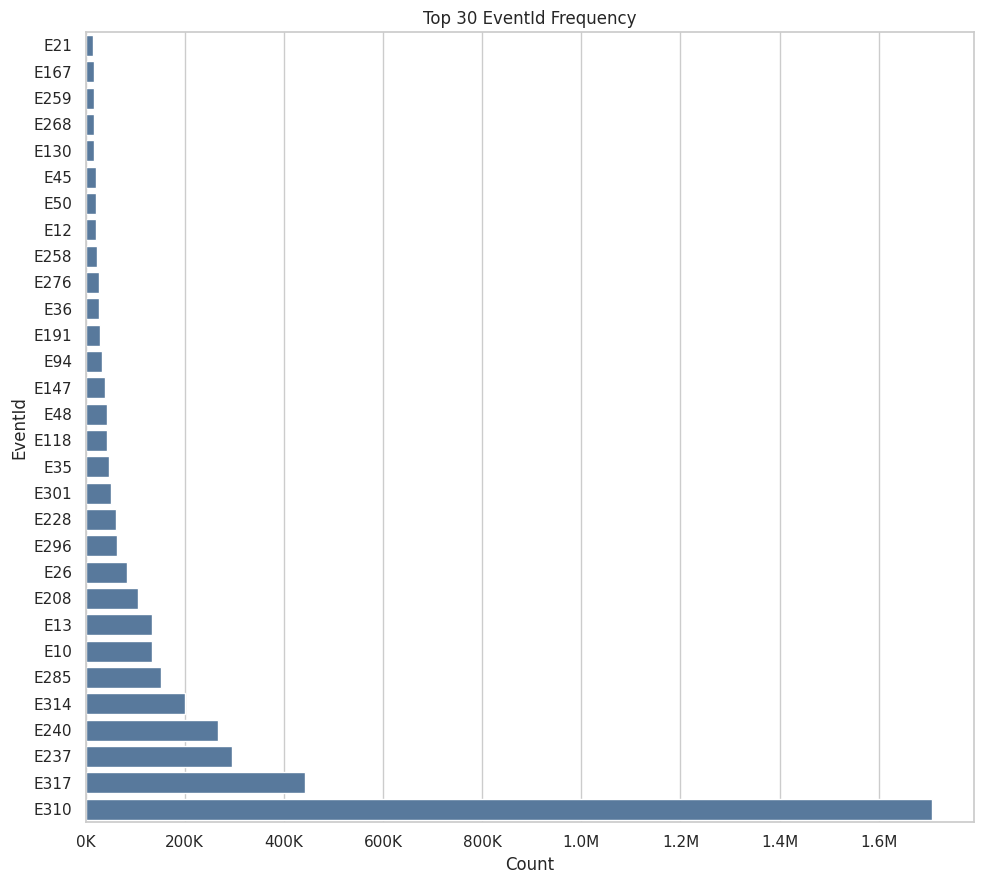

In [7]:
top_n = 30
plot_df = event_counts.head(top_n).sort_values("count")

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=plot_df, x="count", y="event_id", ax=ax, color="#4C78A8")
ax.set_title(f"Top {top_n} EventId Frequency")
ax.set_xlabel("Count")
ax.set_ylabel("EventId")
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1_000_000:.1f}M" if x >= 1_000_000 else f"{x/1_000:.0f}K")
plt.tight_layout()

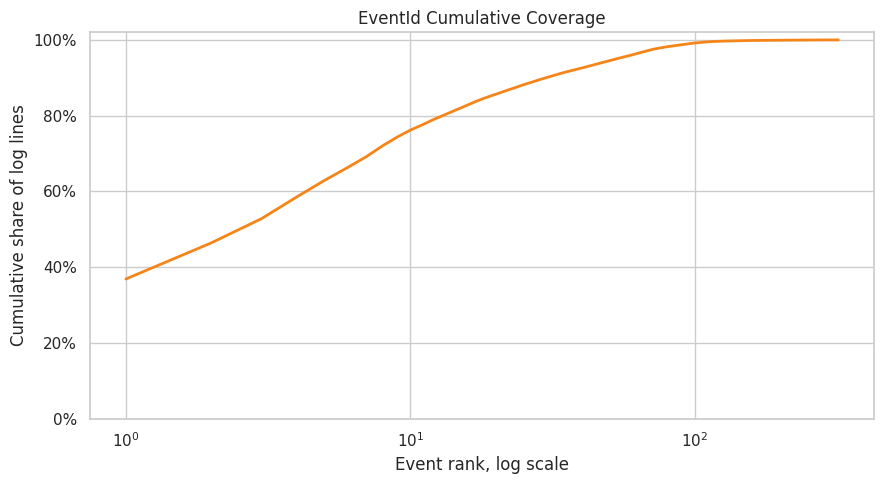

In [8]:
event_counts = event_counts.copy()
event_counts["cumulative_share"] = event_counts["share"].cumsum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(event_counts["rank"], event_counts["cumulative_share"], color="#F58518", linewidth=2)
ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_title("EventId Cumulative Coverage")
ax.set_xlabel("Event rank, log scale")
ax.set_ylabel("Cumulative share of log lines")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
plt.tight_layout()

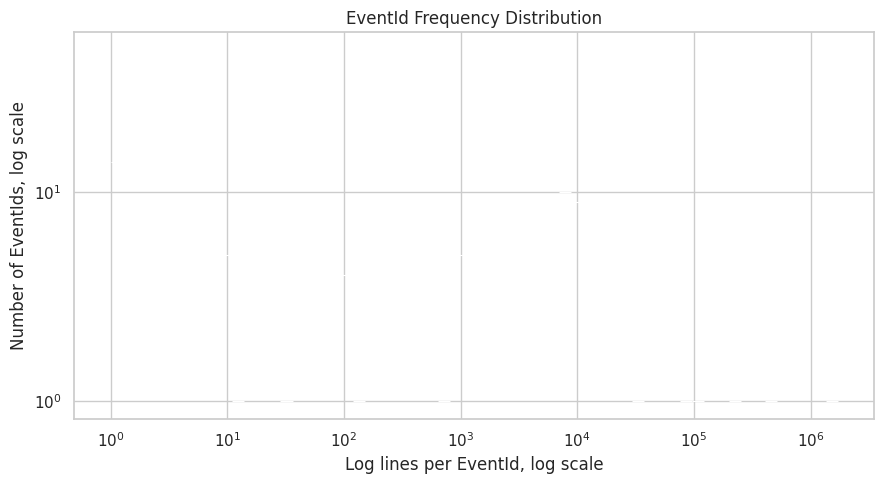

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(event_counts["count"], bins=60, log_scale=(True, True), ax=ax, color="#54A24B")
ax.set_title("EventId Frequency Distribution")
ax.set_xlabel("Log lines per EventId, log scale")
ax.set_ylabel("Number of EventIds, log scale")
plt.tight_layout()

## Template Distribution

In [10]:
template_counts = tables["template_counts"]
template_counts.head(20)

,rank,event_template,count,share
0,1,generating core.<*>,1706751,0.368528
1,2,iar <*> dear <*>,442966,0.095647
2,3,<*> double-hummer alignment exceptions,295764,0.063863
3,4,<*> floating point alignment exceptions,267725,0.057808
4,5,"CE sym <*>, at <*>, mask <*>",201206,0.043445
5,6,data TLB error interrupt,152734,0.032979
6,7,<*> microseconds spent in the rbs signal handler during <*> calls. <*> microseconds was the maximum time for a single instance of a correctable ddr.,135092,0.029170
7,8,"<*> total interrupts. <*> critical input interrupts. <*> microseconds total spent on critical input interrupts, <*> microseconds max time in a critical inpu...",135092,0.029170
8,9,instruction cache parity error corrected,105924,0.022872
9,10,idoproxydb hit ASSERT condition: ASSERT expression=<*> Source file=<*> Source line=<*> Function=<*>,84253,0.018192


/tmp/ipykernel_33289/1571713567.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


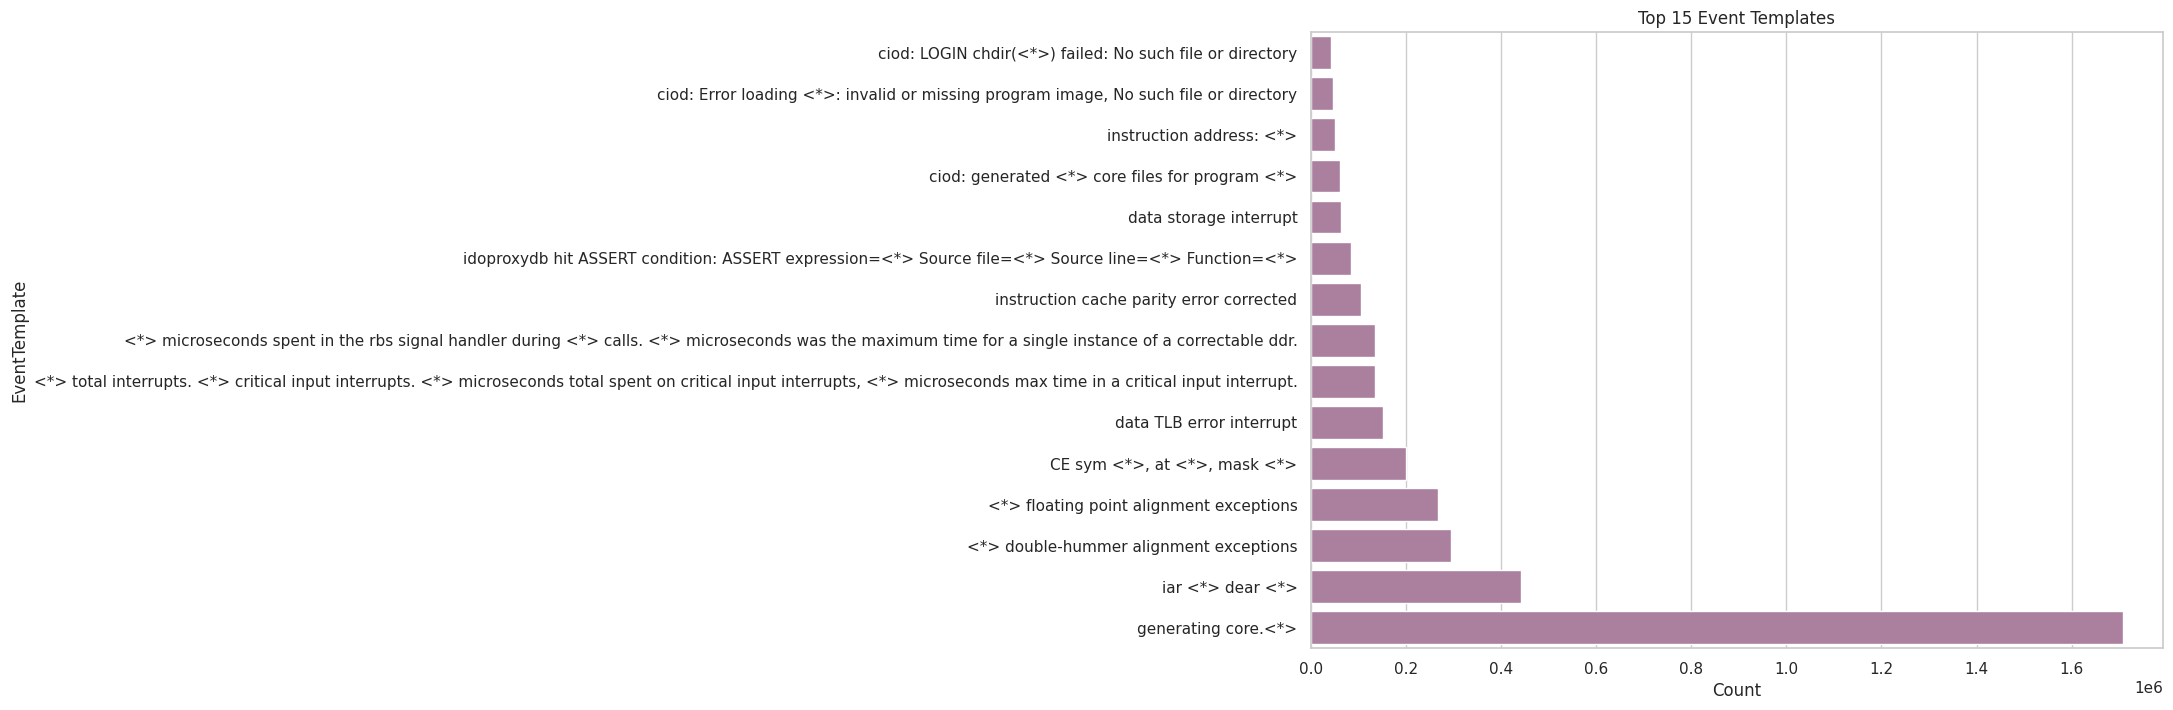

In [11]:
top_templates = template_counts.head(15).sort_values("count")

fig, ax = plt.subplots(figsize=(11, 8))
sns.barplot(data=top_templates, x="count", y="event_template", ax=ax, color="#B279A2")
ax.set_title("Top 15 Event Templates")
ax.set_xlabel("Count")
ax.set_ylabel("EventTemplate")
plt.tight_layout()

## Severity, Component, and Label Distributions

In [12]:
display(tables["level_counts"])
display(tables["label_counts"])
display(tables["component_counts"].head(20))

,rank,level,count,share
0,1,INFO,3699499,7.988103e-01
1,2,FATAL,795015,1.716628e-01
2,3,ERROR,95017,2.051644e-02
3,4,WARNING,21446,4.630704e-03
4,5,SEVERE,18421,3.977534e-03
5,6,FAILURE,1547,3.340343e-04
6,7,Kill,306,6.607272e-05
7,8,single,4,8.636957e-07
8,9,microseconds,4,8.636957e-07
9,10,"0x00544eb8,",2,4.318478e-07


,rank,label,count,share
0,1,-,4299039,9.282653e-01
1,2,KERNDTLB,152734,3.297892e-02
2,3,KERNSTOR,63491,1.370923e-02
3,4,APPSEV,41819,9.029722e-03
4,5,KERNMNTF,31531,6.808297e-03
...,...,...,...,...
27,28,KERNPROG,5,1.079620e-06
28,29,MMCS,3,6.477717e-07
29,30,LINKBLL,2,4.318478e-07
30,31,MASNORM,1,2.159239e-07


,rank,component,count,share
0,1,KERNEL,4246593,9.169410e-01
1,2,APP,210165,4.537965e-02
2,3,MMCS,88865,1.918808e-02
3,4,DISCOVERY,79023,1.706296e-02
4,5,HARDWARE,3272,7.065030e-04
5,6,MONITOR,1521,3.284203e-04
6,7,LINKCARD,1170,2.526310e-04
7,8,FATAL,306,6.607272e-05
8,9,CMCS,211,4.555995e-05
9,10,BGLMASTER,122,2.634272e-05


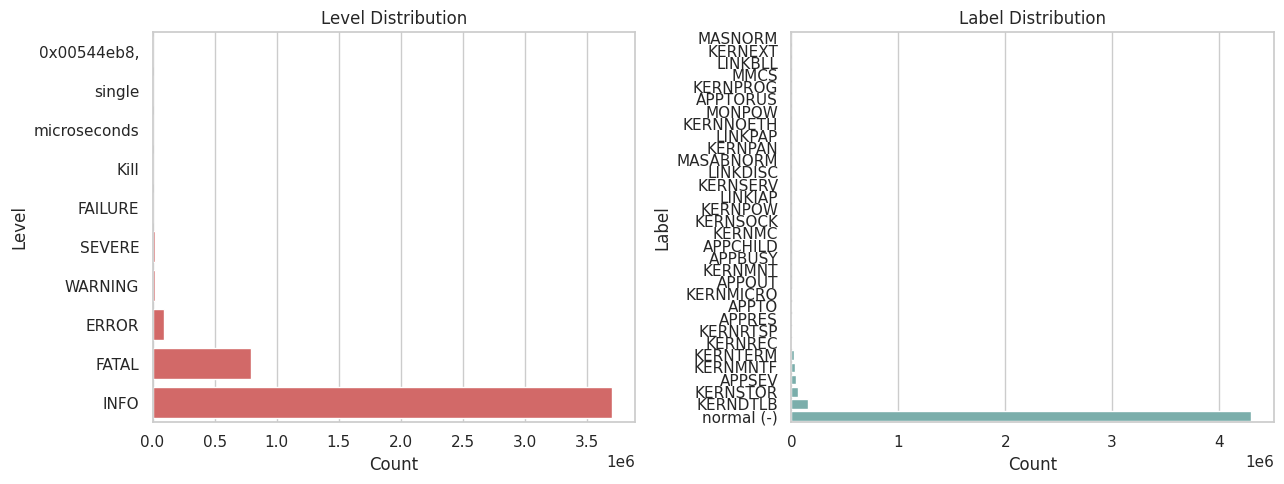

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=tables["level_counts"].sort_values("count"), x="count", y="level", ax=axes[0], color="#E45756")
axes[0].set_title("Level Distribution")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Level")

label_plot = tables["label_counts"].copy()
label_plot["label"] = label_plot["label"].replace({"-": "normal (-)"})
sns.barplot(data=label_plot.sort_values("count"), x="count", y="label", ax=axes[1], color="#72B7B2")
axes[1].set_title("Label Distribution")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Label")

plt.tight_layout()

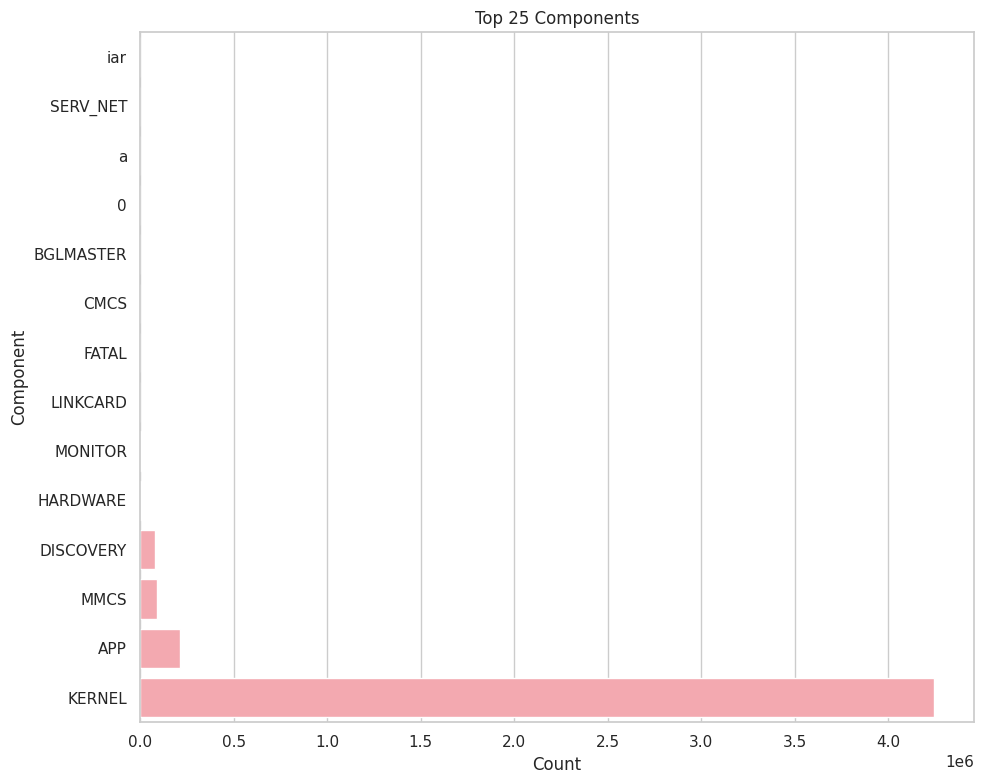

In [14]:
component_plot = tables["component_counts"].head(25).sort_values("count")

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=component_plot, x="count", y="component", ax=ax, color="#FF9DA6")
ax.set_title("Top 25 Components")
ax.set_xlabel("Count")
ax.set_ylabel("Component")
plt.tight_layout()

## Time Trend

In [15]:
daily_counts = tables["daily_counts"].sort_values("date")
daily_counts.head()

,date,total_count,anomaly_count,anomaly_rate
0,2005-06-03,14732,0,0.000000
1,2005-06-04,693,0,0.000000
2,2005-06-05,100471,569,0.005663
3,2005-06-06,39462,5,0.000127
4,2005-06-07,31914,4,0.000125


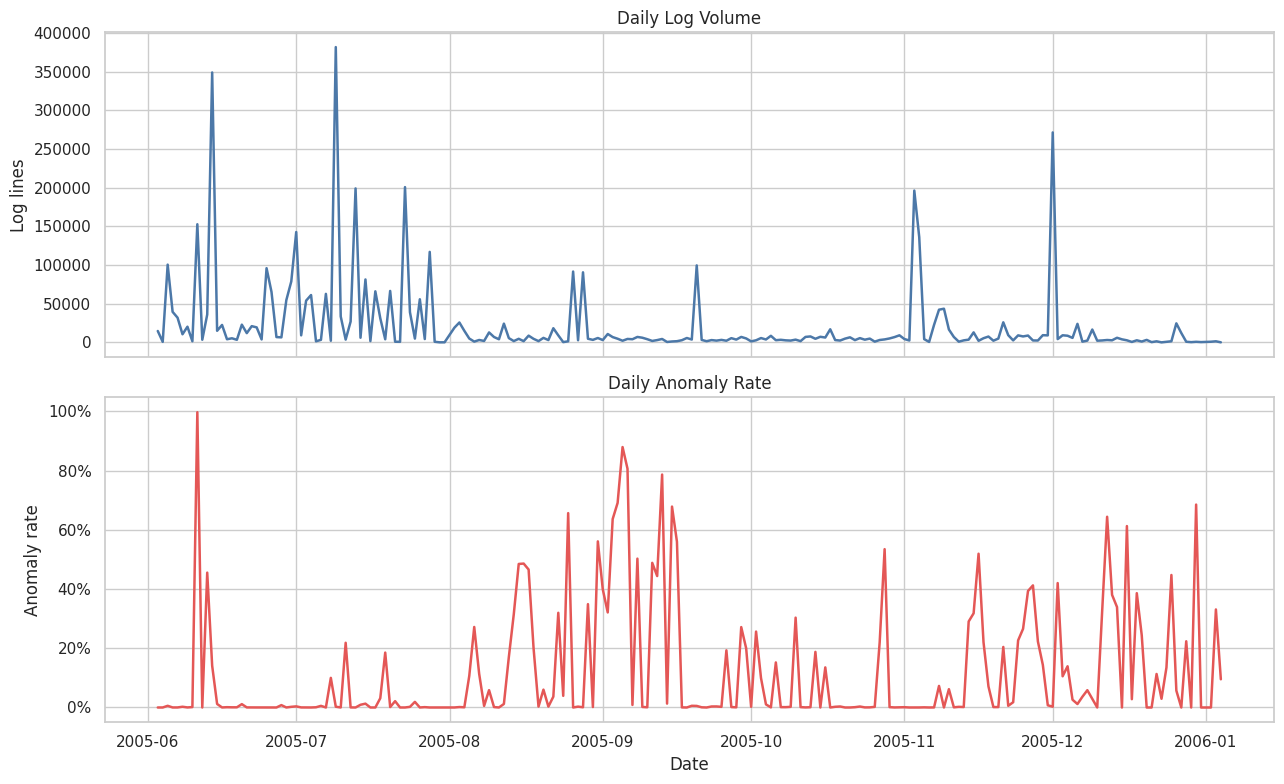

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(daily_counts["date"], daily_counts["total_count"], color="#4C78A8", linewidth=1.8)
axes[0].set_title("Daily Log Volume")
axes[0].set_ylabel("Log lines")

axes[1].plot(daily_counts["date"], daily_counts["anomaly_rate"], color="#E45756", linewidth=1.8)
axes[1].set_title("Daily Anomaly Rate")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Anomaly rate")
axes[1].yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")

plt.tight_layout()

## Message Lengths

In [17]:
pd.DataFrame(
    {
        "content_word_length": summary["content_word_length"],
        "template_word_length": summary["template_word_length"],
    }
)

,content_word_length,template_word_length
count,4.631261e+06,4.631261e+06
mean,5.958016e+00,5.893282e+00
std,6.409643e+00,6.341262e+00
min,1.000000e+00,1.000000e+00
50%,4.000000e+00,4.000000e+00
90%,1.400000e+01,1.300000e+01
95%,2.400000e+01,2.400000e+01
99%,2.500000e+01,2.500000e+01
max,7.700000e+01,6.700000e+01


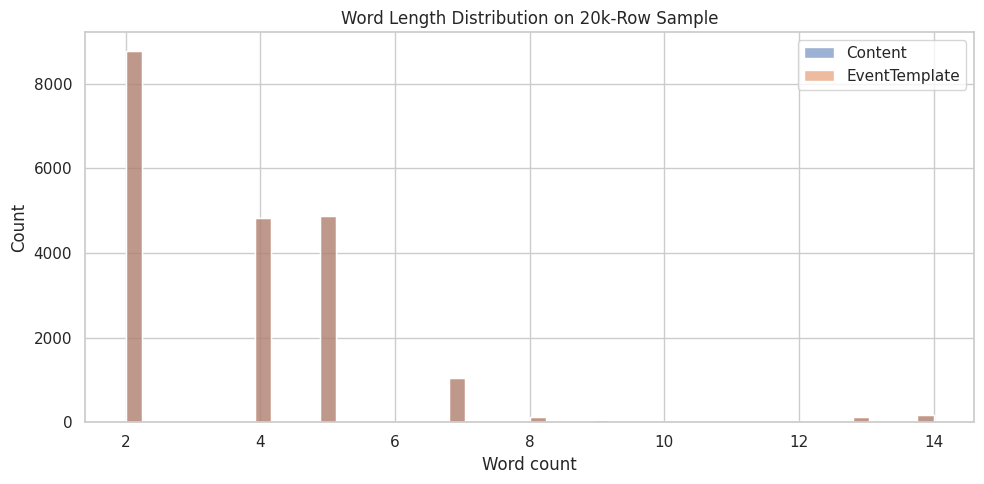

In [18]:
sample_lengths = sample.assign(
    content_word_length=sample["Content"].fillna("").str.split().str.len(),
    template_word_length=sample["EventTemplate"].fillna("").str.split().str.len(),
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(sample_lengths["content_word_length"], bins=50, label="Content", alpha=0.55, ax=ax)
sns.histplot(sample_lengths["template_word_length"], bins=50, label="EventTemplate", alpha=0.55, ax=ax)
ax.set_title("Word Length Distribution on 20k-Row Sample")
ax.set_xlabel("Word count")
ax.legend()
plt.tight_layout()

## Event-Label Cross Analysis

This section uses a larger but still bounded sample by default. Increase `nrows` or remove it if you want a full cross-tab and have enough memory.

In [19]:
cross_sample = pd.read_csv(
    DATA_PATH,
    usecols=["Label", "Level", "Component", "EventId", "EventTemplate"],
    nrows=1_000_000,
    dtype="string",
)
cross_sample["is_anomaly"] = cross_sample["Label"].fillna("-") != "-"

event_anomaly = (
    cross_sample.groupby("EventId", dropna=False)
    .agg(count=("EventId", "size"), anomaly_count=("is_anomaly", "sum"))
    .reset_index()
)
event_anomaly["anomaly_rate"] = event_anomaly["anomaly_count"] / event_anomaly["count"]
event_anomaly.sort_values(["anomaly_rate", "count"], ascending=[False, False]).head(20)

,EventId,count,anomaly_count,anomaly_rate
118,E285,152659,152659,1.0
101,E264,2369,2369,1.0
152,E87,256,256,1.0
119,E286,11,11,1.0
158,E97,4,4,1.0
111,E275,3,3,1.0
21,E129,2,2,1.0
128,E296,63490,63488,0.999968
136,E310,320229,0,0.0
82,E237,66305,0,0.0


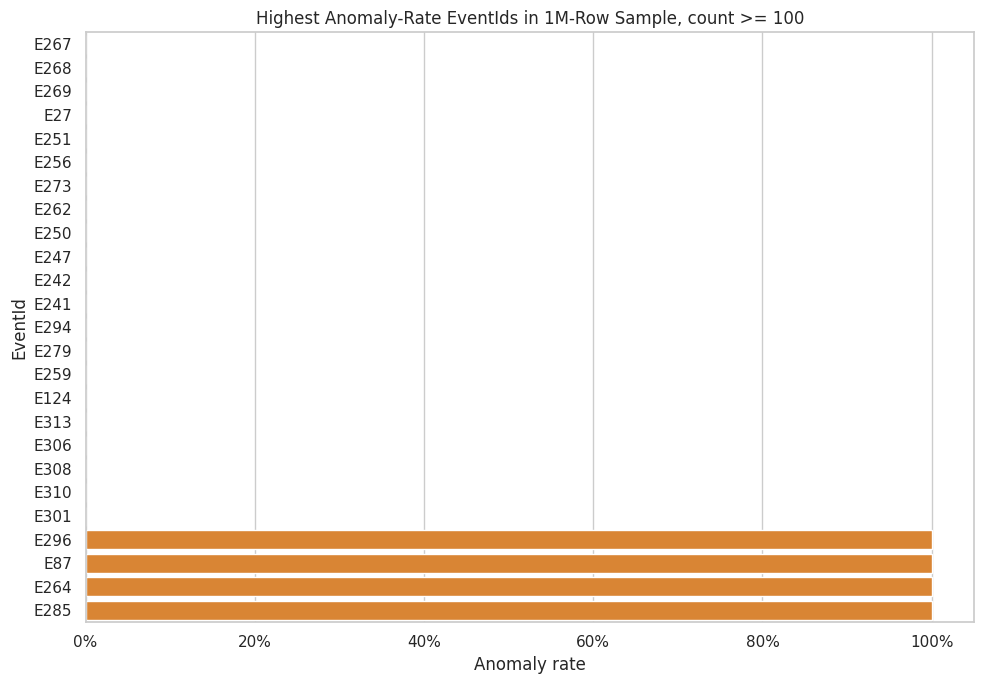

In [20]:
eligible = event_anomaly[event_anomaly["count"] >= 100].sort_values("anomaly_rate", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=eligible.sort_values("anomaly_rate"), x="anomaly_rate", y="EventId", ax=ax, color="#F58518")
ax.set_title("Highest Anomaly-Rate EventIds in 1M-Row Sample, count >= 100")
ax.set_xlabel("Anomaly rate")
ax.set_ylabel("EventId")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()

## Notes for Next Steps

- Use `event_counts` and `template_counts` to choose rare-event filtering thresholds.
- Use `daily_counts` to check whether train/test splits preserve time-varying anomaly rates.
- For modeling, compare raw `EventId` frequency features with component-aware features such as `(Component, EventId)`.